## Model 2: Hierarchical team model (Stan)

**Idea:** a clean hierarchical latent-strength model: long-run team strength (`tau_team`), a shared season-level effect (`tau_season`), and promoted-team status. Unlike Model 1, this model does not use process/lag covariates (`sot_diff_pg`, `pts_lag1`, `ppg_last10`). One model input = **one team**; output = its **points** distribution.

**Backtest:** train through 2024/25 → predict **points** for each 2025/26 team.

**Forecast:** for a new season, use posterior `team_skill[team]`, draw a fresh shared season effect `tau_season * z`, and use `is_promoted`. Promoted or unseen teams get `team_skill = 0` and `beta_promoted` via features.

$$\text{Pts}_{s,t} \sim t_{\nu}\big(\alpha + \text{team\_skill}_{t} + \text{season\_dev}_{s,t} + \gamma^\top x_{s,t},\; \sigma_{\mathrm{pts}}\big)$$

with `is_promoted` plus sum-to-zero constraints for identifiable team and season effects. The process/lag covariates are intentionally excluded to make Model 2 a distinct latent-structure model.
Student-$t$ with $\nu=5$ fixed; $\tau_{\mathrm{team}}$ controls persistent team-strength variation and $\tau_{\mathrm{season}}$ controls shared season-level shifts.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    compute_table,
    predict_team_points,
    build_predicted_table,
    compare_forecast_to_actual,
    forecast_season_summary,
    forecast_team_errors,
    plot_forecast_team_errors,
    print_forecast_season_summary,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [2]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
FEATURE_SEASON = "2425"  # last training season used to identify promoted/new teams

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, season_to_idx, feature_stats = (
    prepare_table_stan_hierarchical(tables, TRAIN_SEASONS)
)
stan_data["nu"] = STUDENT_T_NU
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[FEATURE_SEASON]

print(f"Training rows (team-seasons): {stan_data['N']}")
print(f"Stan keys: {sorted(stan_data.keys())}")
print(f"Teams in training: {stan_data['T']}")
print(f"Seasons in training: {stan_data['S']}")
print(f"Test season {TEST_SEASON}: {len(test_teams)} teams")
print("\nRecent league average points:")
print(tables.groupby("season")["Pts"].mean().tail(3))
print(f"\nPromoted rows in training: {int(np.sum(stan_data['is_promoted']))}")
print(f"Forecast uses season {FEATURE_SEASON} only to identify promoted/new teams")

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Promoted / new teams for forecast (is_promoted=1):", new_in_test)


Training rows (team-seasons): 320
Stan keys: ['N', 'S', 'T', 'is_promoted', 'nu', 'pts', 'season', 'team']
Teams in training: 42
Seasons in training: 16
Test season 2526: 20 teams

Recent league average points:
season
2223    52.65
2324    52.90
2425    52.35
Name: Pts, dtype: float64

Promoted rows in training: 45
Forecast uses season 2425 only to identify promoted/new teams


### Prior selection (Model 2)

| Parameter | Prior | Expert rationale |
|-----------|-------|------------------|
| `intercept` | $\mathcal{N}(50, 25)$ | Pre-data league-scale baseline: a mid-table team is expected somewhere around the middle of the feasible points range, with very wide uncertainty. |
| `beta_promoted` | $\mathcal{N}(-5, 15)$ | Weak football-domain belief that promoted teams may be below average, but the prior allows little, large, or even positive effects. |
| `log_sigma_pts` | $\mathcal{N}(\log 15, 0.8)$ | Very broad residual scale on the points scale, chosen from plausible season-to-season unpredictability rather than fitted to the observed histogram. |
| `log_tau_team` | $\mathcal{N}(\log 12, 0.8)$ | Broad persistent team-strength scale: clubs can plausibly differ by a few to many points before seeing the data. |
| `log_tau_season` | $\mathcal{N}(\log 5, 0.8)$ | Broad shared season-level scale for league-wide shifts; constrained only to avoid impossible numerical scales. |
| `team_skill_z`, `season_effect_z` | sum-to-zero standard Normal vectors | Non-centered geometry with interpretable points-scale multipliers. |

The hierarchy is:

$\text{skill_obs}_{n} = \text{team_skill}_{team[n]} + \text{season_effect}_{season[n]}$.

`team_skill` captures long-run residual quality. `season_effect` captures league-wide season shifts shared by all teams in a season. A previous version included one latent deviation for every team-season row, but that component was weakly identified because each team-season has only one point total and it competed with `sigma_pts`.


### Prior predictive checks

The checks below separate two questions required by the rubric:

- **Parameter priors:** do `sigma_pts`, `tau_team`, `tau_season`, and `beta_promoted` imply football-scale values?
- **Measurement priors:** after combining latent team strength, season effects, and promoted status, do simulated team-season point totals look broadly plausible before conditioning on observed points?


,0.05,0.50,0.95
intercept,8.720730,49.970305,90.849835
beta_promoted,-30.317256,-5.169163,19.500941
sigma_pts,3.735180,12.882119,30.477915
tau_team,3.143257,11.552619,34.428344
tau_season,1.318333,4.831908,16.123010
team_skill_range,13.424036,49.540396,149.029478
season_effect_range,4.304838,16.883692,57.987750


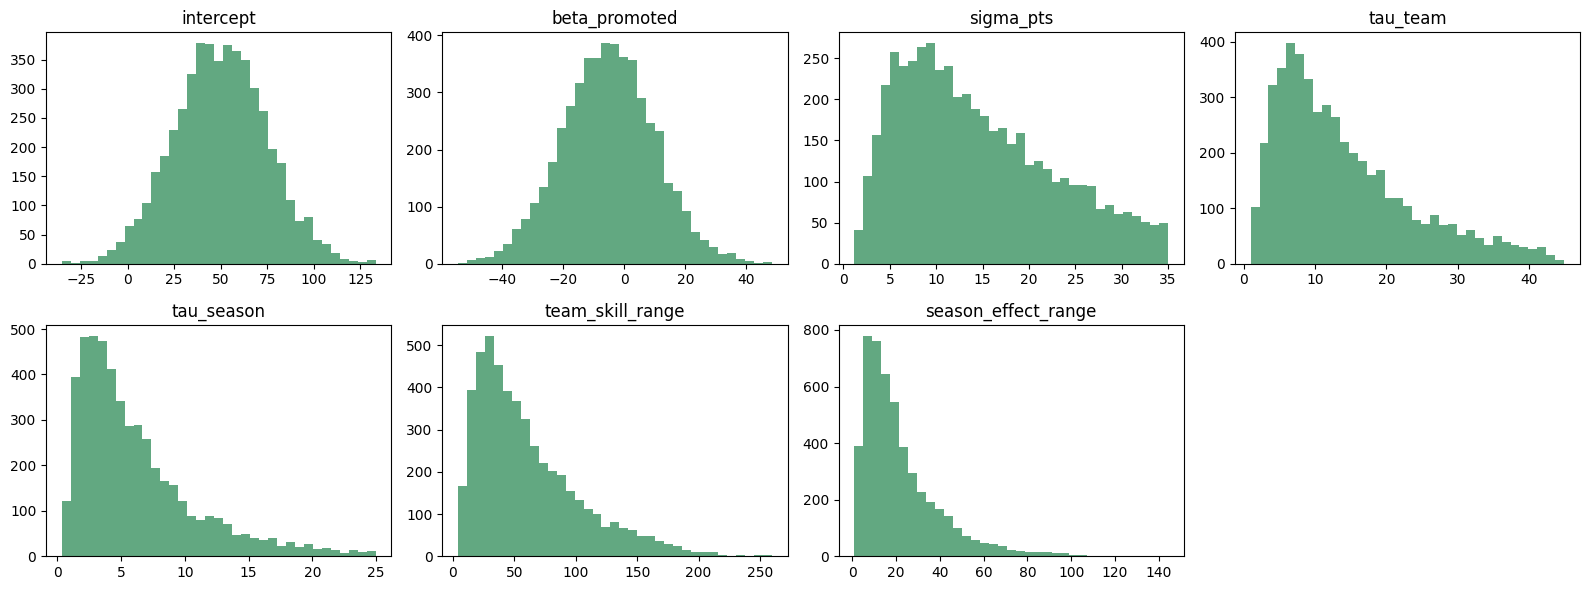

Prior points mean: 49.6; observed mean: 52.4
Prior central 90% interval: -9.2 to 109.7
Observed range: 12 to 100


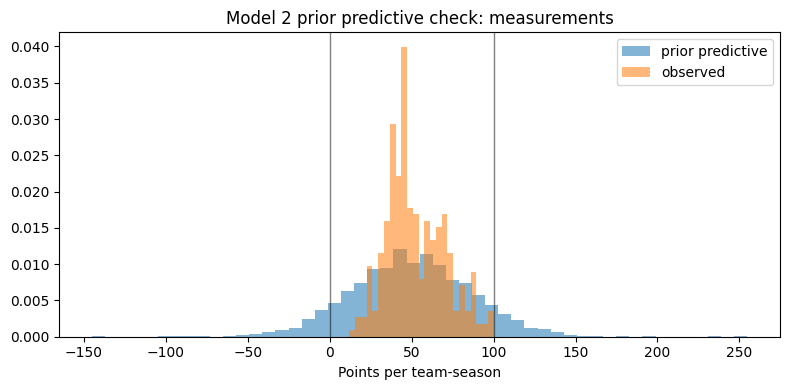

In [3]:
rng = np.random.default_rng(43)
n_prior = 5000
T = stan_data["T"]
S = stan_data["S"]
nu_prior = STUDENT_T_NU

def rtrunc_normal(mean, sd, lower=-np.inf, upper=np.inf, size=1):
    out = np.empty(size)
    filled = 0
    while filled < size:
        draws = rng.normal(mean, sd, size - filled)
        draws = draws[(draws >= lower) & (draws <= upper)]
        take = min(len(draws), size - filled)
        if take:
            out[filled:filled + take] = draws[:take]
            filled += take
    return out

intercept_p = rng.normal(50, 25, n_prior)
beta_promoted_p = rng.normal(-5, 15, n_prior)

sigma_p = np.exp(rtrunc_normal(np.log(15), 0.8, lower=np.log(1), upper=np.log(35), size=n_prior))
tau_team_p = np.exp(rtrunc_normal(np.log(12), 0.8, lower=np.log(0.5), upper=np.log(45), size=n_prior))
tau_season_p = np.exp(rtrunc_normal(np.log(5), 0.8, lower=np.log(0.25), upper=np.log(25), size=n_prior))
team_skill_z = rng.normal(0, 1, (n_prior, T))
team_skill_z -= team_skill_z.mean(axis=1, keepdims=True)
team_skill = tau_team_p[:, None] * team_skill_z
season_effect_z = rng.normal(0, 1, (n_prior, S))
season_effect_z -= season_effect_z.mean(axis=1, keepdims=True)
season_effect = tau_season_p[:, None] * season_effect_z

prior_params = pd.DataFrame({
    "intercept": intercept_p,
    "beta_promoted": beta_promoted_p,
    "sigma_pts": sigma_p,
    "tau_team": tau_team_p,
    "tau_season": tau_season_p,
    "team_skill_range": team_skill.max(axis=1) - team_skill.min(axis=1),
    "season_effect_range": season_effect.max(axis=1) - season_effect.min(axis=1),
})
display(prior_params.quantile([0.05, 0.5, 0.95]).T)

n_params = len(prior_params.columns)
n_cols = 4
n_rows = int(np.ceil(n_params / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, prior_params.columns):
    ax.hist(prior_params[col], bins=35, color="seagreen", alpha=0.75)
    ax.set_title(col)

for ax in axes[n_params:]:
    ax.remove()

plt.tight_layout()
plt.show()

# Measurement prior predictive: sample actual design rows, but draw parameters from prior.
idx = rng.integers(0, stan_data["N"], size=3000)
draw = rng.integers(0, n_prior, size=3000)
teams = np.asarray(stan_data["team"])[idx] - 1
seasons = np.asarray(stan_data["season"])[idx] - 1

skill_obs_prior = team_skill[draw, teams] + season_effect[draw, seasons]
mu_prior = (
    intercept_p[draw]
    + skill_obs_prior
    + beta_promoted_p[draw] * np.asarray(stan_data["is_promoted"])[idx]
)
pts_prior = mu_prior + sigma_p[draw] * rng.standard_t(nu_prior, size=len(draw))

print(f"Prior points mean: {pts_prior.mean():.1f}; observed mean: {np.mean(stan_data['pts']):.1f}")
print(f"Prior central 90% interval: {np.quantile(pts_prior, 0.05):.1f} to {np.quantile(pts_prior, 0.95):.1f}")
print(f"Observed range: {np.min(stan_data['pts']):.0f} to {np.max(stan_data['pts']):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(pts_prior, bins=50, density=True, alpha=0.55, label="prior predictive")
plt.hist(stan_data["pts"], bins=25, density=True, alpha=0.55, label="observed")
plt.axvline(0, color="black", lw=1, alpha=0.5)
plt.axvline(100, color="black", lw=1, alpha=0.5)
plt.xlabel("Points per team-season")
plt.title("Model 2 prior predictive check: measurements")
plt.legend()
plt.tight_layout()
plt.show()


**Prior predictive interpretation (Model 2):** `tau_team` controls persistent club quality on the points scale, `tau_season` controls shared season-level shifts, and `sigma_pts` carries residual team-specific surprises after team strength and promoted status. This check is a sanity check only: priors are not tuned to match the observed histogram; they should merely avoid clearly impossible football-scale predictions.

In [4]:
model = CmdStanModel(stan_file="stan/team_hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


14:22:39 - cmdstanpy - INFO - compiling stan file /workspace/DA_Project/stan/team_hierarchical.stan to exe file /workspace/DA_Project/stan/team_hierarchical
14:22:45 - cmdstanpy - INFO - compiled model executable: /workspace/DA_Project/stan/team_hierarchical
14:22:46 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:22:49 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check divergences (`fit.diagnose()` above), $\hat{R}$, and ESS.
Target: $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$ per parameter.


                    Mean      MCSE    StdDev       MAD          5%        50%  \
intercept       47.28930  0.019280  1.037700  1.045970   45.609300   47.28520   
beta_promoted   -6.89234  0.031802  2.076810  2.061240  -10.309800   -6.86642   
sigma_pts        8.96177  0.005682  0.466166  0.465329    8.226550    8.95559   
tau_team        12.24200  0.046370  1.590070  1.552430    9.885580   12.10740   
tau_season       1.15737  0.006556  0.495858  0.443038    0.498451    1.07543   
lp__          -934.58100  0.197074  7.210350  7.205440 -946.841000 -934.30800   

                     95%  ESS_bulk  ESS_tail     R_hat  
intercept       48.98590   2914.44   4213.41  1.000930  
beta_promoted   -3.47492   4334.75   4710.70  1.000450  
sigma_pts        9.73765   6854.30   4463.17  1.000640  
tau_team        15.06290   1151.99   2790.60  1.002150  
tau_season       2.06844   5059.17   3417.50  0.999929  
lp__          -923.25100   1336.37   2338.17  1.002050  


,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
intercept,47.289,1.038,45.366,49.220,2914.0,4213.0,1.0
beta_promoted,-6.892,2.077,-10.727,-2.975,4335.0,4711.0,1.0
sigma_pts,8.962,0.466,8.044,9.776,6854.0,4463.0,1.0
tau_team,12.242,1.590,9.359,15.194,1152.0,2791.0,1.0
tau_season,1.157,0.496,0.356,2.060,5059.0,3418.0,1.0


Parameters with R-hat > 1.01: 0
Parameters with ESS_bulk < 400: 0


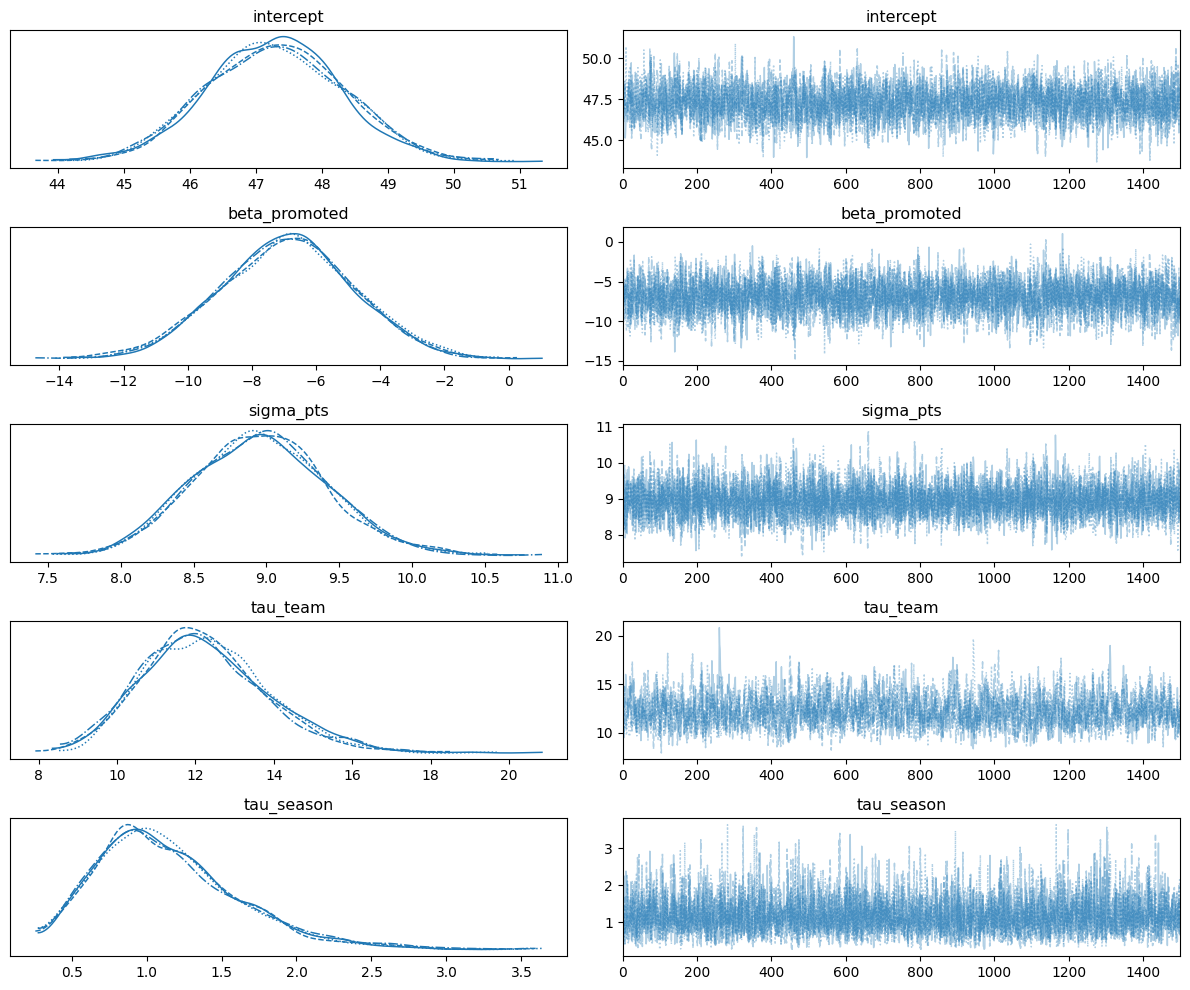

In [5]:
param_vars = [
    "intercept", "beta_promoted",
    "sigma_pts", "tau_team", "tau_season",
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
display(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    display(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    display(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


### Interpreting $\sigma_{\mathrm{pts}}$, $\tau_{\mathrm{team}}$, $\tau_{\mathrm{season}}$, and skills

| Parameter | Order of magnitude | Meaning |
|-----------|-------------------|---------|
| `tau_team` | several to low-double-digit pts | Persistent residual team quality beyond process metrics. |
| `tau_season` | several pts | Shared season-level shift across all teams in a historical season. |
| `team_skill[t]` | learned points-scale range across clubs | Long-run residual club strength on the points scale. |
| `skill[s,t]` | `team_skill + season_effect` | Combined historical skill for season-team rows. |
| `sigma_pts` | learned residual scale | Student-$t$ scale for leftover noise; approximate SD is $\sigma\sqrt{\nu/(\nu-2)}$. |

**Interpretation:** `sigma_pts` is not the raw spread of table points. It is the leftover noise after team quality, season-level shifts, and promoted status. Process/lag covariates are intentionally excluded from Model 2 so that it tests a distinct latent hierarchical structure.


In [6]:
skill_mean = fit.stan_variable("team_skill").mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

skill_table = pd.DataFrame({
    "team": [idx_to_team[j+1] for j in range(len(skill_mean))],
    "team_skill": skill_mean,
}).sort_values("team_skill", ascending=False)
skill_table.head(10)


,team,team_skill
22,Man City,33.823874
0,Arsenal,23.667241
20,Liverpool,23.444047
23,Man United,22.741269
11,Chelsea,22.717583
36,Tottenham,19.280182
13,Everton,5.033774
7,Brentford,4.362161
19,Leicester,2.801422
25,Newcastle,2.574253


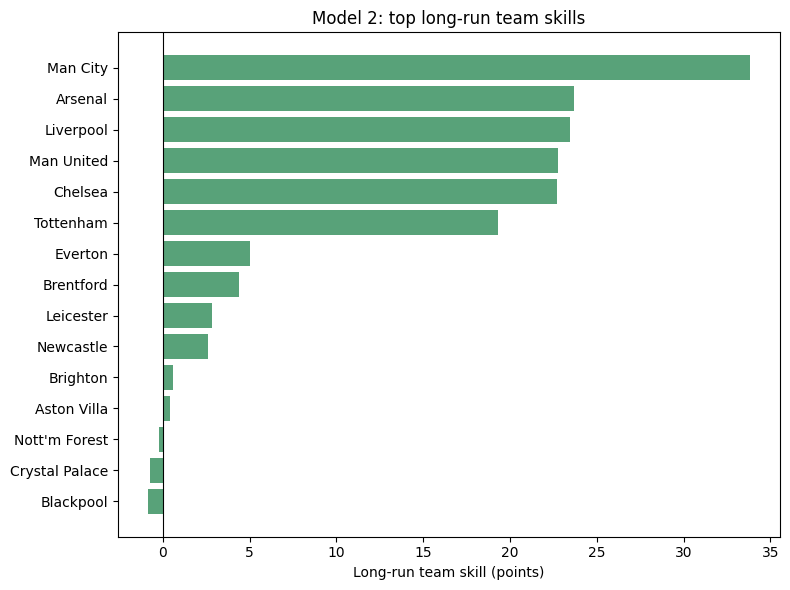

In [7]:
plot_data = skill_table.head(15).sort_values("team_skill")
plt.figure(figsize=(8, 6))
plt.barh(plot_data["team"], plot_data["team_skill"], color="seagreen", alpha=0.8)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Long-run team skill (points)")
plt.title("Model 2: top long-run team skills")
plt.tight_layout()
plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


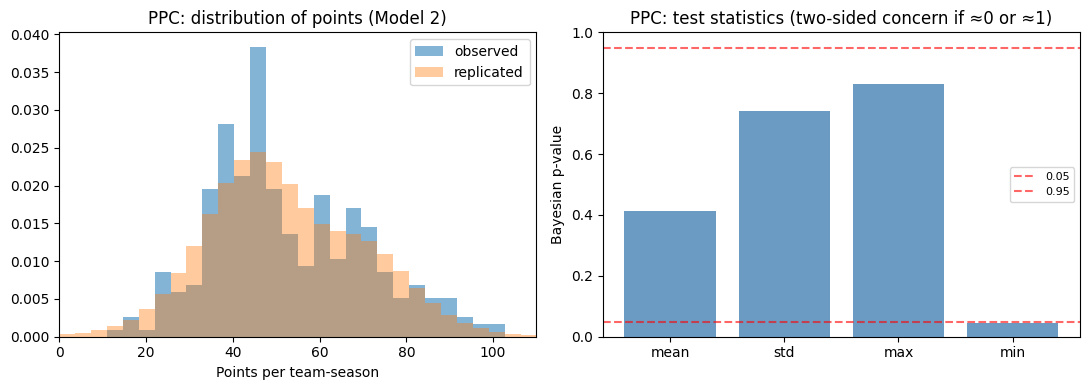

PPC x-axis shown: 0.0 to 110.0 points
Replicated draws outside shown range: 0.42%
  mean: p = 0.414
  std: p = 0.740
  max: p = 0.832
  min: p = 0.046


In [8]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="hierarchical")
y_rep_flat = y_rep.reshape(-1)

# Fixed PPC scale so observed histograms are directly comparable across models.
plot_low, plot_high = 0, 110
bins = np.linspace(plot_low, plot_high, 31)
outside = np.mean((y_rep_flat < plot_low) | (y_rep_flat > plot_high))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=bins, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep_flat, bins=bins, density=True, alpha=0.4, label="replicated")
axes[0].set_xlim(plot_low, plot_high)
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points (Model 2)")
axes[0].legend()

stats = {"mean": np.mean, "std": np.std, "max": np.max, "min": np.min}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6, label="0.05")
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6, label="0.95")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics (two-sided concern if ≈0 or ≈1)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"PPC x-axis shown: {plot_low:.1f} to {plot_high:.1f} points")
print(f"Replicated draws outside shown range: {100 * outside:.2f}%")
for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 2):** same logic as Model 1. If replicated points are too narrow or too wide relative to observed points, the likely culprits are `sigma_pts`, `tau_team`, or `tau_season`. If promoted teams are systematically overpredicted, inspect `beta_promoted`. Good PPC behavior means the hierarchical team-strength plus season-effect model still reproduces the empirical distribution of table points, not only the parameter diagnostics.

### Backtest 2025/26 — per-team points

For each test team we call `predict_team_points` and compare predicted vs actual **points**. Position comparison uses ranking as a derived summary; assembling a full table from 20 predictions is shown in `05_backtest_models_comparison`.

**Forecast skill (Model 2):** posterior `team_skill[team]` plus a fresh shared season-level draw `tau_season * z` for season 2526. Only `is_promoted` is used from `build_forecast_features`; process/lag covariates are ignored by this model, and remaining team-specific uncertainty is represented by the Student-$t$ predictive residual.


In [9]:
forecast_features = build_forecast_features(
    matches, FEATURE_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

# Per-team posterior predictive points
single_rows = []
for j, team in enumerate(test_teams):
    pred = predict_team_points(
        fit,
        team,
        team_to_idx,
        model="hierarchical",
        team_features=forecast_features[team],
        n_sims=500,
        seed=42 + j,
    )
    single_rows.append(pred)
single_df = pd.DataFrame(single_rows)
display(single_df[["team", "pts_median", "pts_mean", "pts_q05", "pts_q95"]].sort_values("pts_median", ascending=False))

pred_table = build_predicted_table(
    fit,
    test_teams,
    team_to_idx,
    model="hierarchical",
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

comparison = compare_forecast_to_actual(pred_table, matches, TEST_SEASON)
season_summary = forecast_season_summary(comparison)
team_errors = forecast_team_errors(comparison)

print_forecast_season_summary(season_summary, season=TEST_SEASON)

display(team_errors)
season_summary


,team,pts_median,pts_mean,pts_q05,pts_q95
12,Man City,80.669993,81.094312,64.443255,98.849524
0,Arsenal,70.703396,69.829849,49.621774,86.710033
13,Man United,70.511820,70.056234,50.622077,87.562834
11,Liverpool,70.279451,70.356529,53.058287,88.582960
6,Chelsea,70.133106,70.636714,51.975589,90.153985
17,Tottenham,66.649067,66.424722,50.373921,83.159915
3,Brentford,51.308601,51.602597,33.411039,70.690784
8,Everton,51.297603,51.723844,32.517150,70.909158
14,Newcastle,50.445896,50.359536,31.325206,67.735843
1,Aston Villa,48.882042,48.489902,28.199683,67.695465


Season 2526 — Point forecast quality
  Sum |point error| over all teams:  203 pts
  Mean |point error| per team:        10.17 pts  (203 / 20)
  Mean signed point error (bias):     +1.17 pts
  Mean predicted / actual points:     53.0 / 51.8
  Sum |position error|:               94 places
  Mean |position error| per team:     4.70 places  (94 / 20)


,team,pts_median,pts_actual,pts_error,pts_abs_error,pos_median,pos_actual,pos_error,pos_abs_error
5,Tottenham,67.147614,41,26.147614,26.147614,6,17,-11,11
15,Wolves,45.286595,20,25.286595,25.286595,16,20,-4,4
19,Sunderland,33.533892,54,-20.466108,20.466108,20,7,13,13
3,Chelsea,70.321149,52,18.321149,18.321149,4,10,-6,6
11,Aston Villa,47.301907,65,-17.698093,17.698093,12,4,8,8
2,Arsenal,70.396345,85,-14.603655,14.603655,3,1,2,2
18,Burnley,33.543614,22,11.543614,11.543614,19,19,0,0
14,Bournemouth,45.800859,57,-11.199141,11.199141,15,6,9,9
1,Liverpool,70.984092,60,10.984092,10.984092,2,5,-3,3
17,Leeds,36.159477,47,-10.840523,10.840523,18,14,4,4


n_teams               20.000000
pts_pred_mean         52.967137
pts_actual_mean       51.800000
pts_mae               10.173507
pts_abs_error_sum    203.470141
pts_bias               1.167137
pos_mae                4.700000
pos_abs_error_sum     94.000000
pos_bias               0.000000
dtype: float64

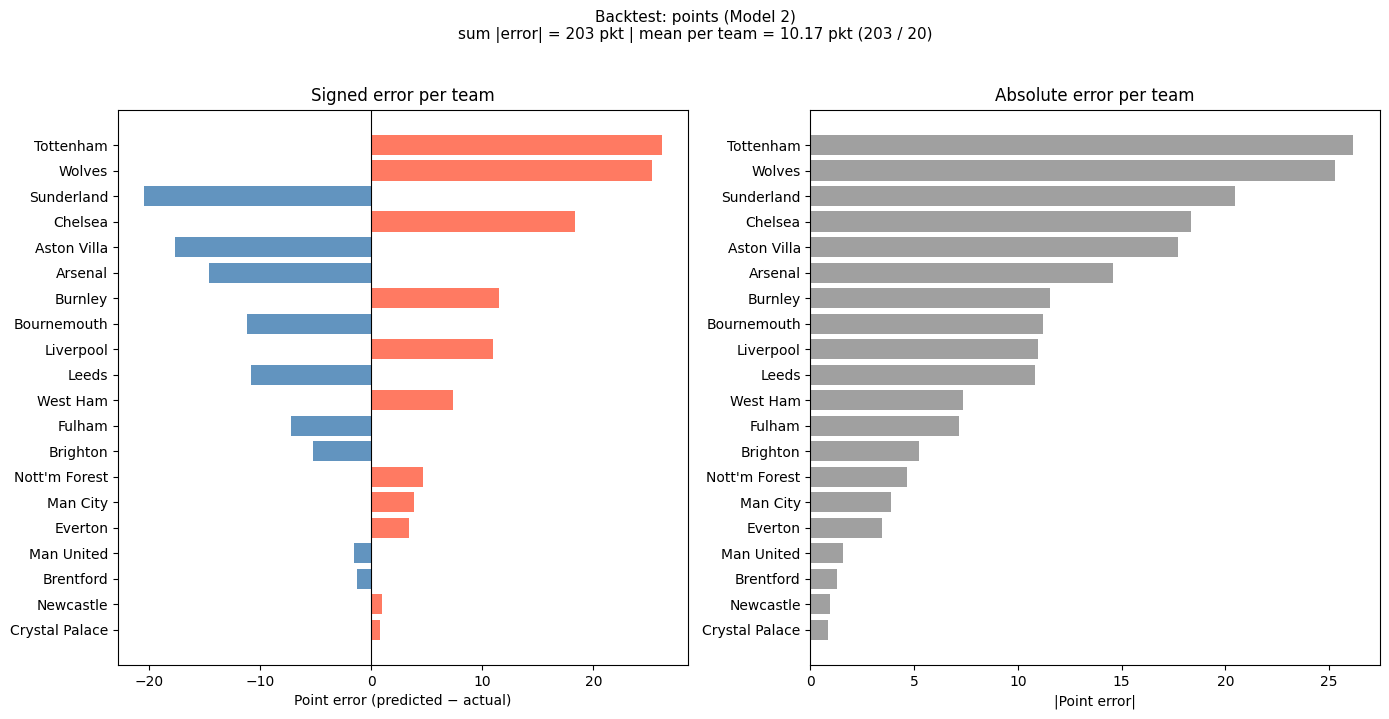

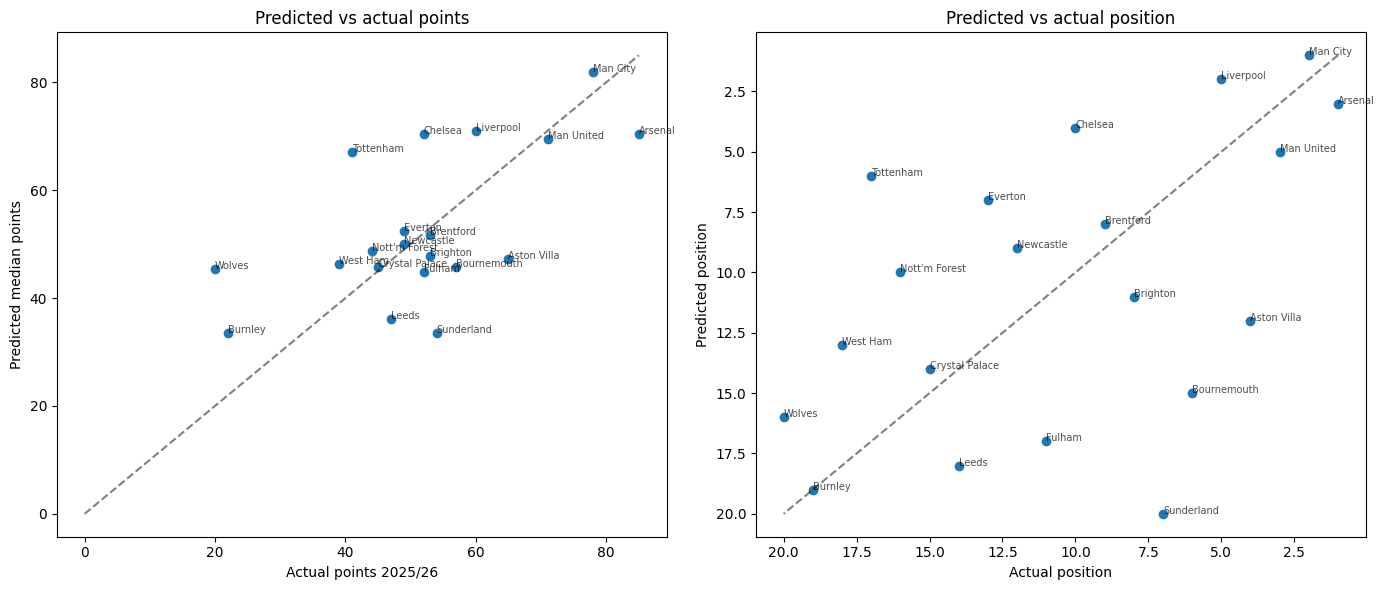

In [10]:
plot_forecast_team_errors(comparison, season=TEST_SEASON, title="Backtest: points (Model 2)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(comparison["pts_actual"], comparison["pts_median"])
for _, r in comparison.iterrows():
    axes[0].annotate(r["team"], (r["pts_actual"], r["pts_median"]), fontsize=7, alpha=0.7)
mx = max(comparison["pts_actual"].max(), comparison["pts_median"].max())
axes[0].plot([0, mx], [0, mx], "k--", alpha=0.5)
axes[0].set_xlabel("Actual points 2025/26")
axes[0].set_ylabel("Predicted median points")
axes[0].set_title("Predicted vs actual points")

axes[1].scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    axes[1].annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
axes[1].plot([1, 20], [1, 20], "k--", alpha=0.5)
axes[1].set_xlabel("Actual position")
axes[1].set_ylabel("Predicted position")
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_title("Predicted vs actual position")
plt.tight_layout()
plt.show()


### WAIC / LOO

This is a single-model diagnostic version of the information criteria. The final comparison between Model 1 and Model 2 is done in `04_forecast_2627_comparison` on the same team-season rows.

For PSIS-LOO, check `pareto_k`: values $\leq 0.7$ are reliable; values above 0.7 indicate influential team-seasons. For WAIC, warnings about high posterior variance of log predictive density mean WAIC may be less stable, so PSIS-LOO and the backtest (`05_backtest_models_comparison`, `04_forecast_2627_comparison`) should receive more weight.

In [11]:
idata = az.from_cmdstanpy(fit)
print(az.waic(idata))
loo = az.loo(idata, pointwise=True)
print(loo)

k = loo.pareto_k.values
n_good = int((k <= 0.7).sum())
n_bad = int(((k > 0.7) & (k <= 1)).sum())
n_very_bad = int((k > 1).sum())
print(f"\nPareto k: good (≤0.7) {n_good}/{len(k)} ({100 * n_good / len(k):.1f}%)")
print(f"           bad (0.7–1] {n_bad}, very bad (>1) {n_very_bad}")


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1238.44    13.76
p_waic       42.55        -

There has been a warning during the calculation. Please check the results.
Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1239.18    13.74
p_loo       43.30        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      320  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Pareto k: good (≤0.7) 320/320 (100.0%)
           bad (0.7–1] 0, very bad (>1) 0
